# dmf research walkthrough — from raw disputes to a documented, deployable model

This notebook runs the **`dmf.research` selection harness end-to-end** on synthetic dispute
data (~3 minutes) and reads every output in the order an analysis naturally unfolds: each
step depends only on what came before it, and the last steps depend on everything.

It doubles as the **specification for a model documentation report**. The sections such a
report needs, and the steps that produce each:

| report section | steps |
|---|---|
| Population overview | 1, 4 |
| Feature importance | 5, 6 |
| Training / CV stability | 6, 7, 12 |
| Out-of-sample performance | 7, 8, 9, 10 |
| Holdout gains and segment parity | 10 |
| Metrics recomputed from stored predictions, per fold | 11, 12 |
| Operating points → the production cut, at **every configured budget** | 13, 14 |
| Monitoring reference | 15, 16 |
| Report manifest (section → artifact → headline numbers) | 17 |

```
data → config → run → partitions → importance → ordering stability → model × k grid
     → marginal gains → 1-SE selection → holdout (OOS, gains, slices)
     → prediction store → per-fold metrics → budget sweep → production cut
     → scorer → monitoring reference → report manifest
```

Run it from the `examples/` folder, top to bottom. Every cell is short on purpose.

In [1]:
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

from dmf import Config, ProductionScorer
from dmf.metrics import metric_names, format_operating_point, population_stability_index, psi_band
from dmf.reporting import summarize_frame, summarize_target, json_safe
from dmf.research import (ModelSelectionHarness, load_predictions, load_fold_assignments,
                          compute_metrics, threshold_at_fpr, operating_point_table,
                          implied_thresholds)
from generate_synthetic_disputes import generate_disputes   # lives beside this notebook

# fixed identity colors: one per model, used consistently in every chart below
C = {"logistic": "#3b6fd4", "gbm": "#c8571b"}
MEASURE = {"recall": "#3b6fd4", "precision": "#c8571b", "flag_rate": "#8a5bd6"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})
pd.set_option("display.width", 160)

TARGET, ID = "is_fraudulent_dispute", "dispute_id"
df = generate_disputes(n=6000, seed=11, prevalence=0.10)
print(f"{df.shape[0]:,} disputes, {df.shape[1]-2} candidate columns, "
      f"prevalence {df[TARGET].mean():.1%}")
df.head(3)

6,000 disputes, 33 candidate columns, prevalence 10.5%


,dispute_id,dispute_amount,txn_amount,amount_to_daily_spend_ratio,days_txn_to_dispute,cardholder_tenure_months,cardholder_tenure_years,prior_disputes_12m,prior_disputes_lifetime,prior_dispute_upheld_ratio,...,noise_gamma,merchant_id,merchant_category,channel,claim_channel,device_type,region,customer_segment,dispute_reason_code,is_fraudulent_dispute
0,D2026000000,172.50,195.96,6.4424,34.1,42.1,3.564,0,0,0.3940,...,9.6041,M100014,digital_goods,recurring,mobile_app,android,southeast,mass,12.5_incorrect_amount,0
1,D2026000001,181.89,182.28,3.2242,3.5,90.0,7.486,1,1,0.7347,...,5.3862,M100036,fuel,card_present,branch,ios,midwest,mass_affluent,10.1_ec_liability,0
2,D2026000002,37.01,41.02,1.7145,9.9,32.7,2.671,0,0,0.4565,...,4.5777,M100012,grocery,card_present,mobile_app,android,northeast,mass_affluent,13.6_credit_not_processed,0


## Step 1 — population overview

**What it is:** the modelling population before anything is fitted or split — target
balance, missingness, and the shape of the candidate columns. **Why it comes first:** it
depends on nothing downstream, and every later number is conditional on it. A report
reader needs to know *what* was modelled before *how well*.

**How to read it:** prevalence sets the difficulty (and why AP, not accuracy, is the
primary metric); columns with material missingness are the ones whose
`missingindicator_` columns may appear later as features; high-cardinality categoricals
are where rare-level collapsing does its work.

target: 632 fraudulent / 6,000 disputes  = 10.53% prevalence  (imbalance 8.5 : 1)
columns: 33  |  overall missing 0.46%  |  duplicate rows 0.00%


,missing_rate,n_unique,mean,p01,p50,p99,skew
dispute_amount,0.000,4469.0,57.975,2.080,29.595,434.712,5.550
txn_amount,0.000,4577.0,62.755,2.270,32.070,458.836,5.713
amount_to_daily_spend_ratio,0.000,5525.0,2.836,0.049,1.166,26.926,6.594
days_txn_to_dispute,0.000,587.0,17.692,1.299,14.700,58.905,1.434
cardholder_tenure_months,0.000,1298.0,48.978,4.300,41.800,161.103,1.409
cardholder_tenure_years,0.000,4256.0,4.082,0.364,3.473,13.442,1.411
prior_disputes_12m,0.000,8.0,0.489,0.000,0.000,4.000,2.640
prior_disputes_lifetime,0.000,9.0,0.980,0.000,1.000,5.000,1.586
prior_dispute_upheld_ratio,0.030,3775.0,0.614,0.195,0.624,0.929,-0.361
avg_monthly_spend,0.000,5892.0,981.013,130.277,731.805,4123.369,3.907


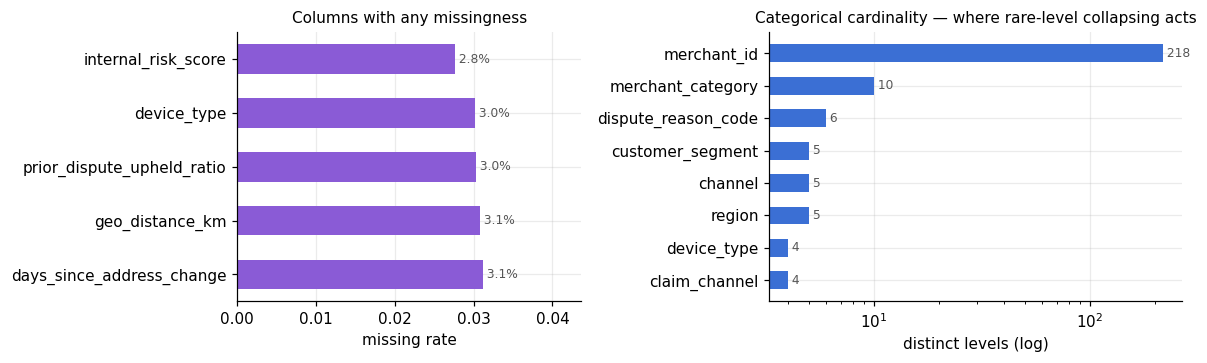

In [2]:
feat = df.drop(columns=[TARGET, ID])
tgt = summarize_target(df[TARGET])
prof = summarize_frame(feat, "candidates")

print(f"target: {tgt['n_positive']:,} fraudulent / {tgt['n_rows']:,} disputes  "
      f"= {tgt['prevalence']:.2%} prevalence  (imbalance {tgt['imbalance_ratio']:.1f} : 1)")
print(f"columns: {prof['n_columns']}  |  overall missing {prof['total_missing_rate']:.2%}  "
      f"|  duplicate rows {prof['duplicate_row_rate']:.2%}")

cols = pd.DataFrame(prof["columns"]).T
cols["kind"] = np.where(cols["dtype"].astype(str).str.startswith(("float", "int")), "numeric", "categorical")
missing = cols["missing_rate"].astype(float).sort_values(ascending=False)
missing = missing[missing > 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1, 1.2]})
axes[0].barh(missing.index, missing.values, color="#8a5bd6", height=0.55)
for y, v in enumerate(missing.values):
    axes[0].text(v, y, f" {v:.1%}", va="center", fontsize=8, color="#555")
axes[0].set_xlim(0, missing.max() * 1.4); axes[0].set_xlabel("missing rate")
axes[0].set_title("Columns with any missingness", fontsize=10)

card = cols.query("kind == 'categorical'")["n_unique"].astype(int).sort_values()
axes[1].barh(card.index, card.values, color="#3b6fd4", height=0.55)
for y, v in enumerate(card.values):
    axes[1].text(v, y, f" {v}", va="center", fontsize=8, color="#555")
axes[1].set_xscale("log"); axes[1].set_xlabel("distinct levels (log)")
axes[1].set_title("Categorical cardinality — where rare-level collapsing acts", fontsize=10)
plt.tight_layout()

cols.query("kind == 'numeric'")[["missing_rate", "n_unique", "mean", "p01", "p50", "p99", "skew"]].astype(float).round(3)

## Step 2 — the config *is* the experiment

Everything the harness does is declared here: which models compete, how many variables to
sweep (`k_min..k_max`), the split design, the metrics, and which segments to audit on the
holdout. Nothing downstream takes arguments — change the experiment by changing this.

We keep it deliberately small: **2 models × k=1..6 × 3-fold CV**, so a human can watch it run.

Three things to notice:

- `data.id_column` names the record identifier — it keys the prediction store and is
  automatically excluded from the candidate features.
- `run.save_predictions: "all"` keeps the row-level scores behind every CV fold and the
  holdout. Steps 11–14 live entirely off that store.
- **The two budget-dependent metrics take lists.** `recall_at_fpr` and `lift_top_pct` are
  curves read at a chosen budget, so each configured budget becomes its own reported metric,
  named `metric@budget`, everywhere: CV scorers, leaderboard columns, the holdout report,
  the store. Where only one number is possible — the shipped decision threshold — the
  **first** entry is used. That is why the lists below are ordered by intent, not by size:
  1% FPR and 5% volume are the operating points we mean to run at; the others are the
  sensitivities a reviewer will ask about.

In [3]:
cfg = Config.from_dict({
    "run": {"name": "walkthrough", "output_dir": "./artifacts_demo", "random_state": 7,
            "n_jobs": 1, "verbose": 0, "save_fitted_model": True,
            "save_predictions": "all"},                      # keep every row-level score
    "data": {"target": TARGET, "id_column": ID},
    "columns": {"auto_infer": True, "drop": ["merchant_id"]},
    "split": {"holdout_size": 0.25, "cv": {"n_splits": 3}},
    "selection": {"k_min": 1, "k_max": 6, "top_n": 3},
    "metrics": {"primary": "average_precision",
                "secondary": ["roc_auc", "ks_statistic", "brier_score",
                              "recall_at_fpr", "lift_at_top_pct"],
                "recall_at_fpr": [0.01, 0.005, 0.02, 0.05],   # first = the shipped FPR point
                "lift_top_pct":  [0.05, 0.02, 0.10],          # first = the shipped review budget
                "decision_threshold_policy": "top_pct",
                "slice_columns": ["customer_segment", "claim_channel"], "min_slice_n": 40},
    "models": {
        "logistic": {"estimator": "sklearn.linear_model.LogisticRegression", "tag": "champion",
                     "family": "linear", "requires_scaling": True, "imbalance": "balanced",
                     "params": {"C": 1.0, "max_iter": 1000}},
        "gbm": {"estimator": "sklearn.ensemble.HistGradientBoostingClassifier", "tag": "challenger",
                "family": "tree", "requires_scaling": False, "imbalance": "balanced",
                "params": {"max_iter": 120, "learning_rate": 0.08, "early_stopping": False}},
    },
})
FPR_BUDGETS, PCT_BUDGETS = cfg.metrics.recall_at_fpr, cfg.metrics.lift_top_pct
print("models:", list(cfg.enabled_models), "| primary:", cfg.metrics.primary,
      "| k sweep: 1..", cfg.selection.k_max, "| store:", cfg.run.save_predictions)
print("\nreported metrics (one column per configured budget):")
for n in metric_names(cfg.metrics):
    print("  ", n)

models: ['logistic', 'gbm'] | primary: average_precision | k sweep: 1.. 6 | store: all

reported metrics (one column per configured budget):
   average_precision
   roc_auc
   ks_statistic
   brier_score
   recall_at_fpr@0.01
   recall_at_fpr@0.005
   recall_at_fpr@0.02
   recall_at_fpr@0.05
   lift_at_top_pct@0.05
   lift_at_top_pct@0.02
   lift_at_top_pct@0.1


## Step 3 — run the harness once

One call does the whole sequence. Internally, per CV fold it: types the columns → ranks the
variables *inside that fold* (so no validation row helps choose the features it scores) →
fits every model at every k → scores the fold. Then it aggregates, tests marginal gains,
applies the 1-SE rule, and confirms the winner on the untouched 25% holdout.

The step log below is the run's audit trail — one line of numbers per step. Skim it now;
we unpack each step next.

In [4]:
result = ModelSelectionHarness(cfg).run(df.copy())
print(result.report.render(max_width=130))

=== step report: walkthrough ===
[lineage] python=3.14.3  platform=Windows-11-10.0.26200-SP0  config_sha256=fedae8650bd658c2  data_rows=6000  data_columns=32  d...
[data_load] name=features  n_rows=6000  n_columns=32  total_missing_rate=0.004693  duplicate_row_rate=0.0
[data_target] name=target  n_rows=6000  n_positive=632  n_negative=5368  prevalence=0.105333  imbalance_ratio=8.493671  positiv...
[data_quality] n_dropped_columns=1  duplicate_row_rate=0.0  duplicate_rows_material=False  total_missing_rate=0.004693
[holdout_split] strategy=random  holdout_size=0.25  stratified=True  n_train=4500  n_holdout=1500  train_prevalence=0.105333  h...
[candidate_variables] n_candidates=32  source=auto_inferred  n_numeric=20  n_categorical=12  n_passthrough=0  n_dropped=0
[estimator_zoo] n_models=2  n_skipped=0
[variable_ordering] mode=per_model  strategy=importance  n_candidates=32  mean_rank_correlation=0.1488  top1_agreement=1.0  top...
[selection_stability] n_folds=3  k_cap=6
[cv_grid] n_var

## Step 4 — partitions: what each number was measured on

**What it is:** the population from Step 1, after the harness split it — the holdout the
final number is quoted on, and the CV folds every leaderboard cell was scored on.
**Why it matters:** every "out-of-sample" claim later is only as strong as these
partitions. Stratification should make prevalence near-identical across them, and each
validation fold needs enough positives for a fold-level AP to mean anything — the harness
flags `thin_positive_folds` when it does not.

In [5]:
rep = result.report
t, s, q, cnd = rep.get("data_target"), rep.get("holdout_split"), rep.get("data_quality"), rep.get("candidate_variables")

parts = pd.DataFrame([
    {"partition": "all",     "n": t["n_rows"],     "positives": t["n_positive"],          "prevalence": t["prevalence"]},
    {"partition": "train",   "n": s["n_train"],    "positives": s["n_train_positive"],    "prevalence": s["train_prevalence"]},
    {"partition": "holdout", "n": s["n_holdout"],  "positives": s["n_holdout_positive"],  "prevalence": s["holdout_prevalence"]},
]).set_index("partition")

fa = (result.fold_assignments.merge(df[[ID, TARGET]], left_on="row_id", right_on=ID)
      .groupby("fold")[TARGET].agg(n="size", positives="sum"))
fa["prevalence"] = fa["positives"] / fa["n"]
fa.index = [f"cv fold {i}" for i in fa.index]

print(f"split: {s['strategy']}, stratified={s['stratified']}, holdout_size={s['holdout_size']}  "
      f"| prevalence gap train↔holdout {s['prevalence_abs_diff']:.4f}")
print(f"candidates: {cnd['n_candidates']} ({cnd['source']})  | dropped columns: {q['dropped_columns']}")
print(f"expected positives per validation fold: {t['expected_positives_per_validation_fold']}  "
      f"| thin folds: {t['thin_positive_folds']}")
pd.concat([parts, fa]).assign(prevalence=lambda x: x["prevalence"].astype(float).round(4))

split: random, stratified=True, holdout_size=0.25  | prevalence gap train↔holdout 0.0000
candidates: 32 (auto_inferred)  | dropped columns: ['merchant_id']
expected positives per validation fold: 158.0  | thin folds: False


,n,positives,prevalence
all,6000,632,0.1053
train,4500,474,0.1053
holdout,1500,158,0.1053
cv fold 0,1500,158,0.1053
cv fold 1,1500,158,0.1053
cv fold 2,1500,158,0.1053


## Step 5 — feature importance: what the ordering is built from

**What it is:** each model, fit once on the full training partition with every candidate,
reports a native importance per variable — |coefficient × SD of the encoded column| for the
linear model (so a rare one-hot dummy is not out-ranked by a scaled numeric), split gain for
the tree. Encoded columns are aggregated back to their source variable, then normalised to
shares. **Why it comes before stability:** this share is the *magnitude*; Step 6 is whether
that magnitude is *reliable* across folds. A report needs both, and they can disagree.

**How to read it:** a marginal ranking that ignores redundancy — two collinear variables can
both score high while only one earns its place in Step 8. `cumulative_share_top5` says how
concentrated the signal is.

{'logistic': ['prior_disputes_12m', 'merchant_category', 'device_changes_90d', 'spend_decile', 'txn_count_30d', 'internal_risk_score'], 'gbm': ['prior_disputes_12m', 'internal_risk_score', 'days_txn_to_dispute', 'night_txn_share_30d', 'card_present_share_30d', 'geo_distance_km']}


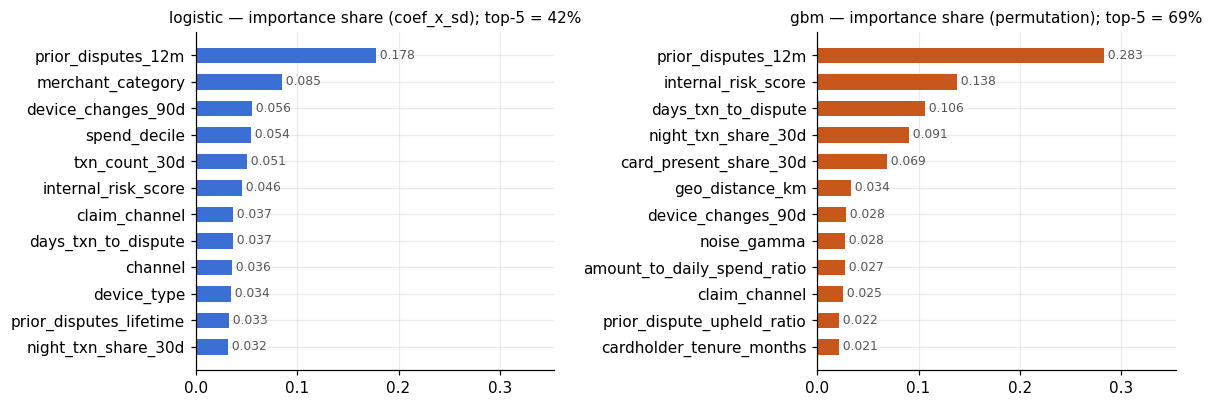

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for ax, (model, o) in zip(axes, result.orderings.items()):
    r = o["report"]
    share = pd.Series(r["importance_share"]).sort_values().tail(12)
    ax.barh(share.index, share.values, color=C[model], height=0.6)
    for y, v in enumerate(share.values):
        ax.text(v, y, f" {v:.3f}", va="center", fontsize=8, color="#555")
    ax.set_title(f"{model} — importance share ({r['method']}); top-5 = {r['cumulative_share_top5']:.0%}",
                 fontsize=10)
    ax.set_xlim(0, share.max() * 1.25)
plt.tight_layout()
print({m: o["ordering"][:6] for m, o in result.orderings.items()})

## Step 6 — variable ordering & stability

**What it is:** inside each fold, each model ranks all candidate variables; the top-k prefix
of that ranking defines which variable subsets the grid evaluates. **Why it matters
downstream:** the grid can only score subsets the ordering proposes — an unstable ordering
means the "k=4 model" is a different 4 variables in every fold.

**How to read it:** the chart shows the share of folds in which each variable survived into
the top-k. Bars at 1.0 = the backbone of the model, selected every time. Bars near 0.3 =
fold-dependent noise — be suspicious if one of these ends up in the final spec. Compare
against Step 5: a variable with high importance share but low selection frequency is
being carried by a lucky partition.

selected in every fold: {'logistic': ['device_changes_90d', 'merchant_category', 'prior_disputes_12m', 'spend_decile'], 'gbm': ['days_txn_to_dispute', 'internal_risk_score', 'prior_disputes_12m']}


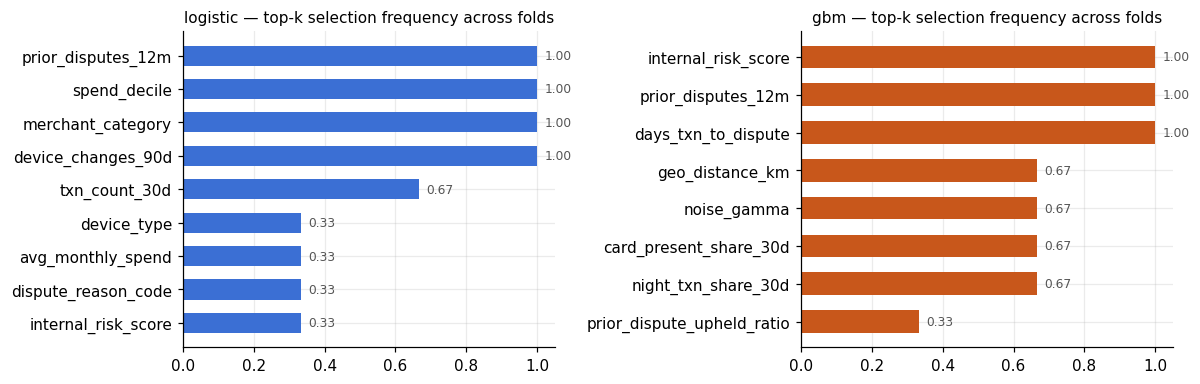

In [7]:
stab = result.report.get("selection_stability")["selection_frequency"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for ax, (model, freqs) in zip(axes, stab.items()):
    sf = pd.Series(freqs).sort_values()
    ax.barh(sf.index, sf.values, color=C[model], height=0.6)
    ax.set_title(f"{model} — top-k selection frequency across folds", fontsize=10)
    ax.set_xlim(0, 1.05)
    for y, v in enumerate(sf.values):
        ax.text(v + 0.02, y, f"{v:.2f}", va="center", fontsize=8, color="#555")
plt.tight_layout()
always = result.report.get("selection_stability")["always_selected"]
print("selected in every fold:", always)

## Step 7 — the leaderboard: performance vs number of variables

**What it is:** every (model × k) cell scored by fold-nested CV. **How to read it:** each
curve is one model; the error bars are the **Nadeau–Bengio corrected** standard error
(folds share training data, so the naive SE would be ~⅓ too narrow). Look for where each
curve *plateaus* — variables past the bend are candidates for cutting, which is exactly
what the next two steps decide formally.

Note the column list: every configured budget has its own `cv_<metric>@<budget>_mean / _std
/ _se` triple. The leaderboard is ranked on the primary metric only; the budget columns
travel alongside so Step 13 can read them without a refit.

budget columns on the leaderboard: ['cv_recall_at_fpr@0.01_mean', 'cv_recall_at_fpr@0.005_mean', 'cv_recall_at_fpr@0.02_mean', 'cv_recall_at_fpr@0.05_mean', 'cv_lift_at_top_pct@0.05_mean', 'cv_lift_at_top_pct@0.02_mean', 'cv_lift_at_top_pct@0.1_mean']


,rank,model,k,cv_average_precision_mean,cv_average_precision_se,overfit_gap,cv_recall_at_fpr@0.01_mean,cv_recall_at_fpr@0.005_mean
0,1,logistic,6,0.331938,0.032210,0.029969,0.154008,0.082278
1,2,logistic,5,0.325533,0.041322,0.033445,0.145570,0.056962
2,3,logistic,4,0.317575,0.031679,0.034135,0.132911,0.063291
3,4,logistic,3,0.311965,0.030667,0.024165,0.127025,0.069620
4,5,logistic,2,0.309154,0.029535,0.013460,0.151260,0.084051
5,6,gbm,3,0.285284,0.021033,0.517427,0.118143,0.054852


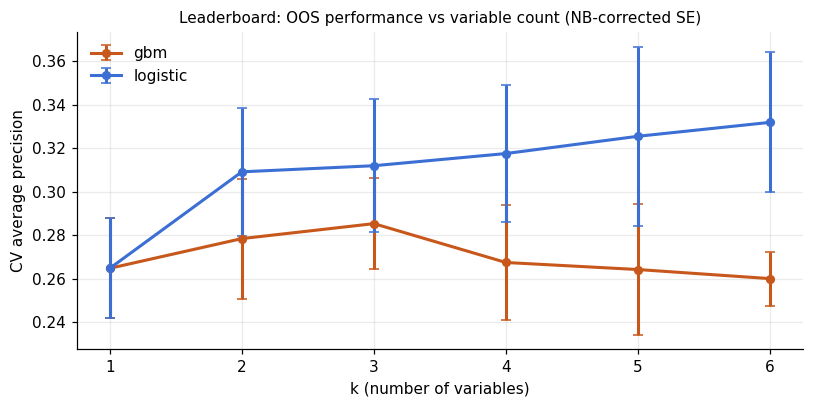

In [8]:
lb = result.leaderboard
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for model, g in lb.groupby("model"):
    g = g.sort_values("k")
    ax.errorbar(g["k"], g["cv_average_precision_mean"], yerr=g["cv_average_precision_se"],
                color=C[model], marker="o", ms=5, lw=2, capsize=3, label=model)
ax.set_xlabel("k (number of variables)"); ax.set_ylabel("CV average precision")
ax.set_title("Leaderboard: OOS performance vs variable count (NB-corrected SE)", fontsize=10)
ax.legend(frameon=False)
plt.tight_layout()

budget_cols = [c for c in lb.columns if "@" in c and c.endswith("_mean")]
print("budget columns on the leaderboard:", budget_cols)
lb[["rank", "model", "k", "cv_average_precision_mean", "cv_average_precision_se",
    "overfit_gap"] + budget_cols[:2]].head(6)

**Also check `overfit_gap`** (train − OOS score): a cell with strong CV performance *and* a
large gap is memorising — the selection rule below only sees the OOS number, so the gap is
your independent sanity check on any spec you're about to trust.

## Step 8 — marginal gains: does the k-th variable earn its place?

**What it is:** for the best model, the paired fold-level change in AP going from k−1 → k
variables, with a Nadeau–Bengio corrected t-test. **How to read it:** solid bars are
statistically significant improvements; faded bars are noise. This is the plateau from
Step 7 made precise — and it's the evidence the 1-SE rule (next) uses implicitly: once
gains stop being significant, extra variables are cost without benefit.

,from_k,to_k,added_variable,mean_delta,p_value,verdict
0,1,2,merchant_category,0.044449,0.103102,not_significant
1,2,3,device_changes_90d,0.002811,0.879231,not_significant
2,3,4,spend_decile,0.005610,0.685782,not_significant
3,4,5,txn_count_30d,0.007959,0.666472,not_significant
4,5,6,internal_risk_score,0.006405,0.658270,not_significant


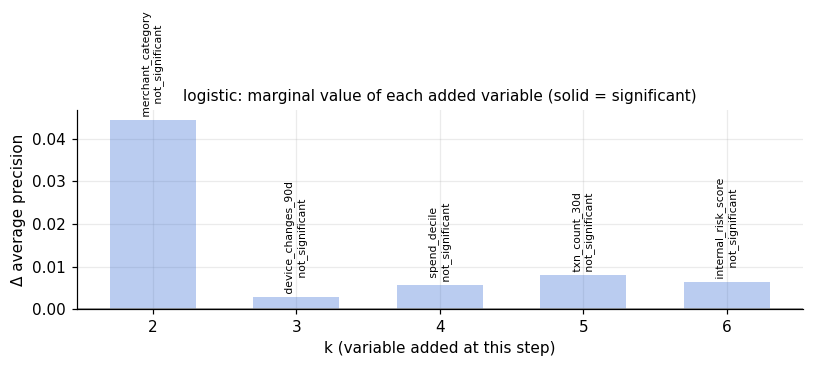

In [9]:
best_model = result.selected["model"]
g = result.marginal_gains.query("model == @best_model").sort_values("to_k")
fig, ax = plt.subplots(figsize=(7.5, 3.4))
bar_colors = [to_rgba(C[best_model], 1.0 if v == "improves" else 0.35) for v in g["verdict"]]
ax.bar(g["to_k"], g["mean_delta"], color=bar_colors, width=0.6)
ax.axhline(0, color="#888", lw=1)
for _, r in g.iterrows():
    ax.text(r["to_k"], r["mean_delta"], f' {r["added_variable"]}\n {r["verdict"]}',
            fontsize=7, rotation=90, va="bottom" if r["mean_delta"] >= 0 else "top", ha="center")
ax.set_xlabel("k (variable added at this step)"); ax.set_ylabel("Δ average precision")
ax.set_title(f"{best_model}: marginal value of each added variable (solid = significant)", fontsize=10)
plt.tight_layout()
g[["from_k", "to_k", "added_variable", "mean_delta", "p_value", "verdict"]]

## Step 9 — selection: the one-standard-error rule

**What it is:** among all specs within one (corrected) SE of the outright best, take the one
with the **fewest variables**. Simpler models are cheaper to monitor, explain, and defend —
and within one SE, "best" is statistically indistinguishable from "simplest".

**How to read the chart:** the shaded band is [best − 1 SE, best]. Any point inside the band
is a legitimate choice; the rule picks the leftmost. `cost_of_parsimony` quantifies exactly
how much headline AP was traded for the smaller spec.

selected : logistic  k=2  (one_standard_error)
variables: prior_disputes_12m, merchant_category
cost of parsimony vs unconstrained best: 0.0228 AP, saving 4 variables


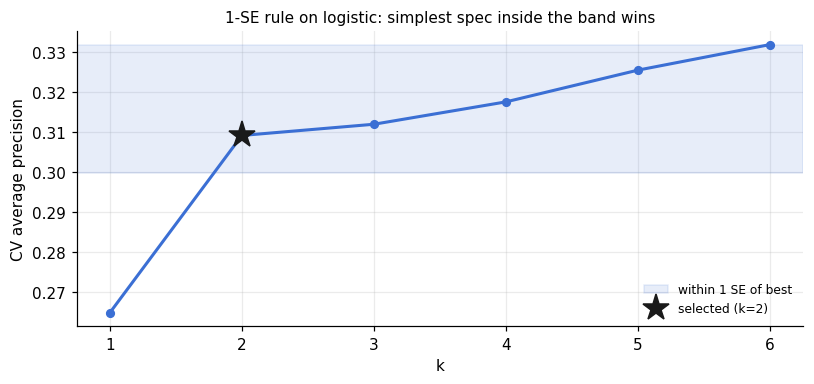

In [10]:
sel = result.selected
k_sel = sel["k"]
gb = lb.query("model == @best_model").sort_values("k")
best = gb["cv_average_precision_mean"].max()
se = gb.loc[gb["cv_average_precision_mean"].idxmax(), "cv_average_precision_se"]

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.axhspan(best - se, best, color=C[best_model], alpha=0.12, label="within 1 SE of best")
ax.plot(gb["k"], gb["cv_average_precision_mean"], color=C[best_model], marker="o", ms=5, lw=2)
ax.plot(sel["k"], sel["cv_average_precision_mean"], marker="*", ms=18, color="#1a1a1a",
        ls="none", label=f"selected (k={sel['k']})")
ax.set_xlabel("k"); ax.set_ylabel("CV average precision")
ax.set_title(f"1-SE rule on {best_model}: simplest spec inside the band wins", fontsize=10)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
print(f"selected : {sel['model']}  k={sel['k']}  ({sel['rule']})")
print(f"variables: {', '.join(sel['features'])}")
print(f"cost of parsimony vs unconstrained best: {sel['cost_of_parsimony']:.4f} AP, "
      f"saving {sel['unconstrained_best']['k'] - sel['k']} variables")

## Step 10 — holdout confirmation: OOS performance, gains, and segment parity

Everything above used only the 75% training partition. The selected spec is now refit and
scored **once** on the untouched 25% holdout — this is the number to quote, because no
part of the selection ever saw these rows. Three readings:

- **CV vs holdout:** if holdout lands near the CV estimate, the process didn't overfit its
  own search. A big shortfall means the leaderboard flattered itself. Every configured
  budget is reported here too — `recall_at_fpr@…` and `lift_at_top_pct@…` — which is the
  raw material for Step 13.
- **Gains:** how concentrated is fraud in the top score bands (lift per decile), and how
  much of it is captured by reviewing the top *x*% (cumulative capture)? This is the
  operational reading of AP.
- **Slices:** the same holdout broken down by segment. A strong global AP can hide a big
  flag-rate disparity in one segment — the first thing a fairness/model-risk review asks.
  A segment with no fraud in the holdout keeps its row (its flag rate is still meaningful)
  but reports `null` for AP and AUC rather than a fabricated 0.

CV estimate 0.3092  →  holdout 0.3193   (roc_auc 0.713, ks 0.372, brier 0.2049)
holdout at every configured budget:
   recall_at_fpr@0.01       0.1232
   recall_at_fpr@0.005      0.0886
   recall_at_fpr@0.02       0.1728
   recall_at_fpr@0.05       0.2566
   lift_at_top_pct@0.05     4.1772
   lift_at_top_pct@0.02     6.0127
   lift_at_top_pct@0.1      3.2278


max flag-rate disparity across slice columns: 1.605 x


,band,n,score_min,score_max,n_positive,positive_rate,lift,cumulative_capture
0,1,150,0.676962,0.959367,51,0.340000,3.2278,0.322785
1,2,150,0.527808,0.590240,31,0.206667,1.9620,0.518987
2,3,150,0.446811,0.527808,15,0.100000,0.9494,0.613924
3,4,150,0.445974,0.446811,8,0.053333,0.5063,0.664557
4,5,150,0.412755,0.445974,8,0.053333,0.5063,0.715190
5,6,150,0.394120,0.412755,13,0.086667,0.8228,0.797468
6,7,150,0.384758,0.394120,3,0.020000,0.1899,0.816456
7,8,150,0.312206,0.384758,15,0.100000,0.9494,0.911392
8,9,150,0.298323,0.312206,9,0.060000,0.5696,0.968354
9,10,150,0.267479,0.298323,5,0.033333,0.3165,1.000000


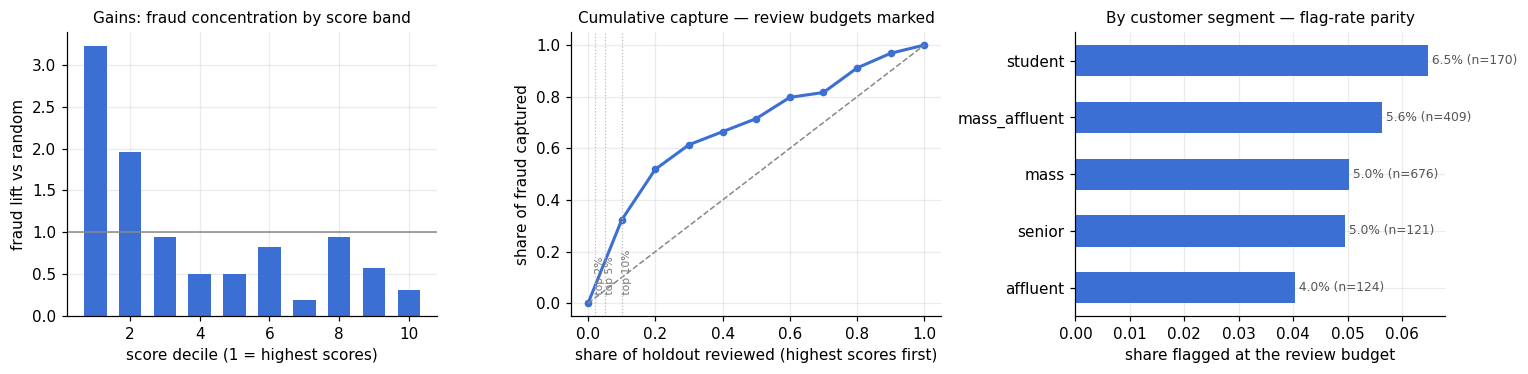

In [11]:
hm = result.holdout_metrics
print(f"CV estimate {sel['cv_average_precision_mean']:.4f}  →  holdout {hm['average_precision']:.4f}"
      f"   (roc_auc {hm['roc_auc']:.3f}, ks {hm['ks_statistic']:.3f}, brier {hm['brier_score']:.4f})")
print("holdout at every configured budget:")
for k_, v in hm.items():
    if "@" in k_:
        print(f"   {k_:<24s} {v:.4f}")

d = result.holdout_deciles
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].bar(d["band"], d["lift"], color=C[best_model], width=0.65)
axes[0].axhline(1, color="#888", lw=1)
axes[0].set_xlabel("score decile (1 = highest scores)"); axes[0].set_ylabel("fraud lift vs random")
axes[0].set_title("Gains: fraud concentration by score band", fontsize=10)

vol = d["n"].cumsum() / d["n"].sum()
axes[1].plot(np.r_[0, vol], np.r_[0, d["cumulative_capture"]], color=C[best_model], lw=2, marker="o", ms=4)
axes[1].plot([0, 1], [0, 1], color="#888", lw=1, ls="--")
for p in PCT_BUDGETS:
    axes[1].axvline(p, color="#bbb", lw=0.8, ls=":")
    axes[1].text(p, 0.02, f" top {p:.0%}", fontsize=7, color="#777", rotation=90, va="bottom")
axes[1].set_xlabel("share of holdout reviewed (highest scores first)"); axes[1].set_ylabel("share of fraud captured")
axes[1].set_title("Cumulative capture — review budgets marked", fontsize=10)

sl = result.holdout_slices.query("slice_column == 'customer_segment'").sort_values("flag_rate_at_top_pct")
axes[2].barh(sl["level"], sl["flag_rate_at_top_pct"], color=C[best_model], height=0.55)
for y, (v, n) in enumerate(zip(sl["flag_rate_at_top_pct"], sl["n"])):
    axes[2].text(v, y, f" {v:.1%} (n={n})", va="center", fontsize=8, color="#555")
axes[2].set_xlabel("share flagged at the review budget")
axes[2].set_title("By customer segment — flag-rate parity", fontsize=10)
plt.tight_layout()
print("max flag-rate disparity across slice columns:",
      result.report.get("holdout_slices")["max_flag_rate_disparity"], "x")
d

## Step 11 — the prediction store: every score the harness computed, kept

`run.save_predictions: "all"` told the harness to keep the row-level evidence behind every
number above: for each CV fold of every model × k cell (and for the holdout), one row of
`(row_id, y_true, y_score)` plus the provenance that makes it analysable. Two schema
decisions to understand:

- **Scores, not labels.** Selection never picks a probability threshold — every metric
  above either integrates over *all* thresholds (AP, ROC-AUC, KS) or fixes an *operating
  point* (an FPR budget, a review capacity) and lets the threshold fall out. Storing raw
  scores keeps every operating point computable forever; storing labels would bake one in.
- **`y_true` travels with the score**, so nothing below needs the raw data or the model.

`predictions_meta.json` records what the numbers *mean* — the resolved positive label, the
score semantics, the full budget lists in force, the policy that produced the decision
threshold and **which budget it was derived at** (`decision_operating_point`). The store is
also on the result object (`result.predictions`); we load from disk here to make the point
that post-run analysis needs only the artifact folder.

In [12]:
RUN_DIR = "./artifacts_demo/walkthrough"
preds, meta = load_predictions(RUN_DIR)
folds = load_fold_assignments(RUN_DIR)

print(preds.groupby("stage").size().rename("rows").to_string())
print("\nrow identity  :", meta["row_id_source"])
print("positive label:", meta["positive_label"], "→", meta["score_semantics"])
print("budgets in force:", {k: meta["metrics"][k] for k in ("recall_at_fpr", "lift_top_pct")})
print(f"decision threshold: {meta['decision_threshold']}  ({meta['decision_threshold_policy']} policy, "
      f"derived at budget {hm['decision_operating_point']})")
preds.head(4)

stage
cv           54000
cv_train    108000
holdout       1500

row identity  : data.id_column:dispute_id
positive label: 1 → y_score is predict_proba[:, 1] for the positive label; y_true is 1 where the raw target equals positive_label
budgets in force: {'recall_at_fpr': [0.01, 0.005, 0.02, 0.05], 'lift_top_pct': [0.05, 0.02, 0.1]}
decision threshold: 0.822057  (top_pct policy, derived at budget 0.05)


,row_id,y_true,y_score,stage,model,k,fold,repeat
0,D2026005003,0,0.499056,cv,logistic,1,0,0
1,D2026005303,0,0.373887,cv,logistic,1,0,0
2,D2026002384,0,0.499056,cv,logistic,1,0,0
3,D2026000029,0,0.373887,cv,logistic,1,0,0


## Step 12 — metrics on demand: recompute, expand, drill down

`compute_metrics` runs the stored rows through the **same metric registry the harness
used**, so start with the trust check: per-fold AP from the store, averaged per (model, k),
must reproduce the leaderboard exactly. Then the payoff — metrics **this run never
computed**: pass any `MetricsConfig` (or the run's own `meta`, which carries the budgets)
and the store supports the whole registry, at any budget, at any granularity (`by=`
controls the drill-down). Budgets you never configured are one list entry away.

In [13]:
cv_preds = preds[preds["stage"] == "cv"]
per_fold = compute_metrics(cv_preds, meta, by=["model", "k", "repeat", "fold"])

check = (per_fold.groupby(["model", "k"])["average_precision"].mean().reset_index()
         .merge(lb[["model", "k", "cv_average_precision_mean"]], on=["model", "k"]))
print("store reproduces the leaderboard:",
      np.allclose(check["average_precision"], check["cv_average_precision_mean"], atol=2e-6))

# metrics and budgets the run was never configured for -- derived from the store alone
from dmf.config import MetricsConfig
expanded = MetricsConfig(
    primary="average_precision",
    secondary=["roc_auc", "recall_at_fpr", "lift_at_top_pct", "log_loss", "calibration_error"],
    recall_at_fpr=[0.002, 0.01, 0.03, 0.10],      # a different sweep than the run used
    lift_top_pct=[0.01, 0.05],
)
compute_metrics(preds[preds["stage"] == "holdout"], expanded, by=["model", "k"]).round(4).T

store reproduces the leaderboard: True


,0
model,logistic
k,2
n,1500
n_positive,158
average_precision,0.3193
roc_auc,0.7125
recall_at_fpr@0.002,0.0795
recall_at_fpr@0.01,0.1232
recall_at_fpr@0.03,0.2032
recall_at_fpr@0.1,0.3881


**Drill-down: the uncertainty the leaderboard summarised away.** Each dot below is one
fold's AP; the line joins the fold means (the leaderboard values). **How to read it:** a
spec whose dots sit tightly together generalises consistently. A spec with one high fold
and two low ones is being carried by a lucky partition — its leaderboard mean flatters it,
and the corrected SE from Step 7 is the honest width of exactly this spread. The table
beneath is the per-fold view for the selected cell across *every* configured metric — the
"training / CV stability" section of a report in one frame.

fold,0,1,2,mean,std
average_precision,0.2724,0.3333,0.3217,0.3092,0.0324
roc_auc,0.6769,0.6762,0.6805,0.6779,0.0023
ks_statistic,0.2858,0.2954,0.3208,0.3007,0.0181
brier_score,0.2019,0.2030,0.2030,0.2026,0.0006
recall_at_fpr@0.01,0.0979,0.1844,0.1714,0.1513,0.0466
recall_at_fpr@0.005,0.0655,0.0845,0.1021,0.0841,0.0183
recall_at_fpr@0.02,0.1512,0.2262,0.1896,0.1890,0.0375
recall_at_fpr@0.05,0.2647,0.3354,0.3089,0.3030,0.0357
lift_at_top_pct@0.05,4.3038,5.1899,4.5570,4.6835,0.4564
lift_at_top_pct@0.02,5.0633,6.9620,6.6456,6.2236,1.0173


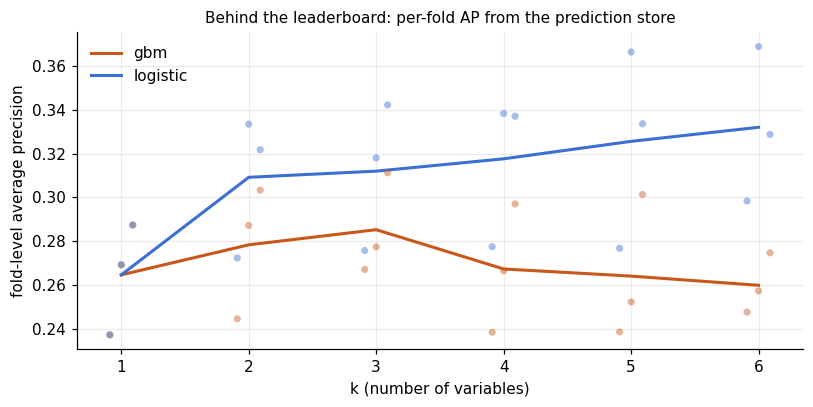

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for model, g in per_fold.groupby("model"):
    means = g.groupby("k")["average_precision"].mean()
    ax.plot(means.index, means.values, color=C[model], lw=2, label=model, zorder=2)
    x = g["k"] + (g["fold"].astype(int) - 1) * 0.09          # de-overlap the 3 folds
    ax.scatter(x, g["average_precision"], color=C[model], s=22, alpha=0.45,
               edgecolors="none", zorder=3)
ax.set_xlabel("k (number of variables)"); ax.set_ylabel("fold-level average precision")
ax.set_title("Behind the leaderboard: per-fold AP from the prediction store", fontsize=10)
ax.legend(frameon=False)
plt.tight_layout()

sel_folds = (per_fold.query("model == @best_model and k == @k_sel")
             .set_index("fold").drop(columns=["model", "k", "repeat", "n", "n_positive"]))
sel_folds.loc["mean"] = sel_folds.mean(); sel_folds.loc["std"] = sel_folds.iloc[:-1].std()
sel_folds.round(4).T

**Overfit, recomputed at will.** The `all` capture level also stored each fold's
*training-side* predictions (`stage == "cv_train"`), so the train-vs-validation gap is
rebuildable per fold and per k without refitting anything. **How to read it:** the
vertical distance between the curves is the generalisation gap; a gap that widens as k
grows means added variables are being memorised, not learned. The leaderboard's
`overfit_gap` column is this same quantity — now yours to slice any way a review asks.

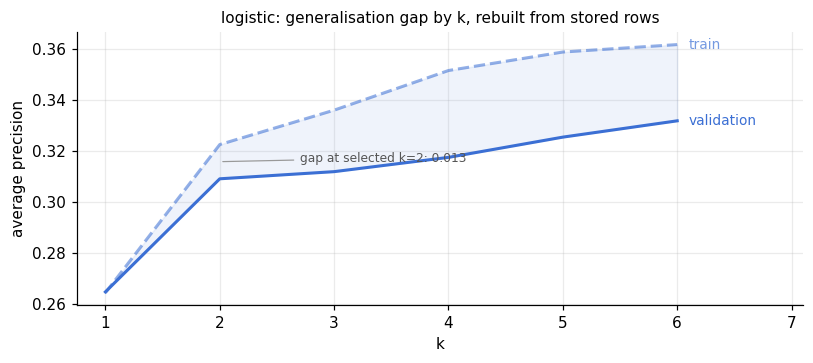

In [15]:
tr = compute_metrics(preds.query("stage == 'cv_train' and model == @best_model"),
                     meta, by=["k", "fold"])
va = per_fold.query("model == @best_model")
tr_m = tr.groupby("k")["average_precision"].mean()
va_m = va.groupby("k")["average_precision"].mean()

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(tr_m.index, tr_m.values, color=C[best_model], lw=2, ls="--", alpha=0.55)
ax.plot(va_m.index, va_m.values, color=C[best_model], lw=2)
ax.fill_between(va_m.index, va_m.values, tr_m.values, color=C[best_model], alpha=0.08)
ax.text(tr_m.index[-1] + 0.1, tr_m.iloc[-1], "train", color=C[best_model], alpha=0.7, fontsize=9, va="center")
ax.text(va_m.index[-1] + 0.1, va_m.iloc[-1], "validation", color=C[best_model], fontsize=9, va="center")
ax.annotate(f"gap at selected k={k_sel}: {tr_m[k_sel] - va_m[k_sel]:.3f}",
            xy=(k_sel, (tr_m[k_sel] + va_m[k_sel]) / 2),
            xytext=(k_sel + 0.7, (tr_m[k_sel] + va_m[k_sel]) / 2),
            fontsize=8, color="#555", arrowprops=dict(arrowstyle="-", color="#999", lw=0.8))
ax.set_xlim(right=tr_m.index.max() + 1.1)
ax.set_xlabel("k"); ax.set_ylabel("average precision")
ax.set_title(f"{best_model}: generalisation gap by k, rebuilt from stored rows", fontsize=10)
plt.tight_layout()

## Step 13 — the budget sweep: one curve, every configured operating point

**What it is:** the selected model's holdout precision–recall curve, with each configured
budget marked as a point *on* it. This is the section a reviewer reads to understand what
the model buys at each operating point — and it is the reason budgets are lists.

**What moves and what does not.** AP, ROC-AUC and KS integrate over *all* thresholds, so
they are the same number at every budget — do not expect a "PR-AUC per FPR rate"; it would
be a flat line. What changes as the budget loosens is the **threshold**, and everything
downstream of it: recall rises, precision falls, flag rate rises, and the achieved FPR
tracks the budget. Loosening the budget walks *right* along one fixed curve.

**How to read the table:**

- `threshold` is the holdout score cut that achieves the budget; `fold_thr_min/max` is the
  same cut re-derived on each CV fold. A narrow spread means the operating point is a
  property of the *model*; a wide one means it is a property of the *partition* — and the
  tighter the budget, the fewer negatives define it, so expect the spread to widen at
  0.5% FPR.
- `cv_recall` (from the leaderboard) vs `holdout_recall` is the CV↔holdout check *at that
  budget*, not just globally.
- The `top x% volume` rows are the review-capacity family. The shipped decision cut comes
  from the first of these (`top_pct` policy); the FPR rows are the sensitivities.

,threshold,fold_thr_min,fold_thr_max,cv_recall,holdout_recall,precision,flag_rate,achieved_fpr,cv_lift,holdout_lift
label,,,,,,,,,,
FPR ≤ 1.0%,0.8896,0.8427,0.9031,0.1513,0.1232,0.6129,0.0207,0.0089,NaN,NaN
FPR ≤ 0.5%,0.9122,0.9158,0.9296,0.0841,0.0886,0.7368,0.0127,0.0037,NaN,NaN
FPR ≤ 2.0%,0.8416,0.8107,0.8516,0.1890,0.1728,0.5094,0.0353,0.0194,NaN,NaN
FPR ≤ 5.0%,0.7823,0.7238,0.7595,0.3030,0.2566,0.3824,0.0680,0.0469,NaN,NaN
top 5% volume,0.8221,0.7956,0.8161,NaN,0.2152,0.4304,0.0527,0.0335,4.6835,4.1772
top 2% volume,0.8913,0.8893,0.9055,NaN,0.1203,0.6129,0.0207,0.0089,6.2236,6.0127
top 10% volume,0.5989,0.5959,0.6091,NaN,0.3228,0.3400,0.1000,0.0738,3.4810,3.2278


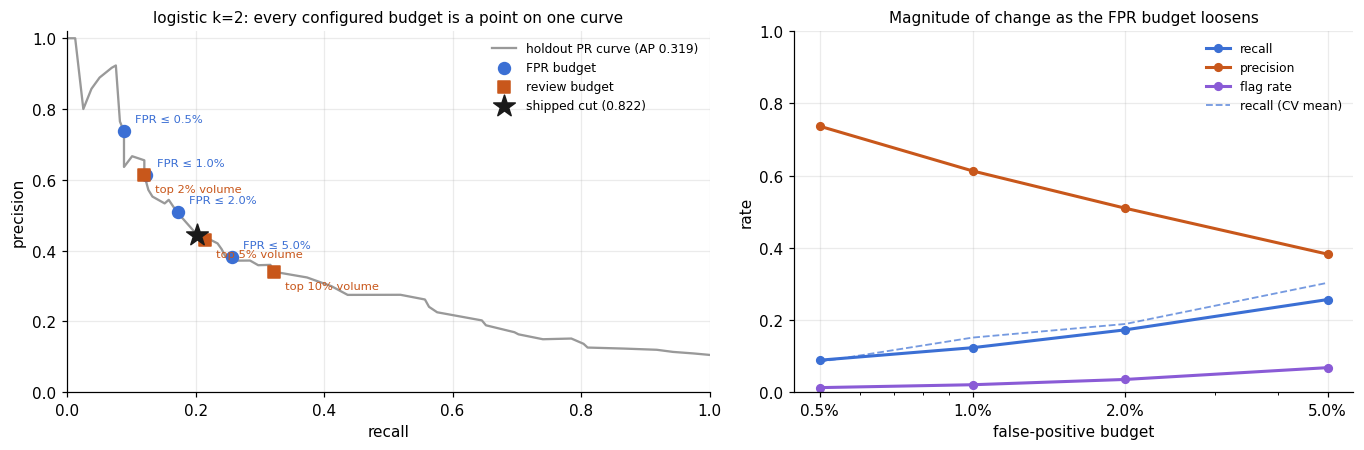

In [16]:
ho = preds[preds["stage"] == "holdout"]
y_ho, s_ho = ho["y_true"].to_numpy(), ho["y_score"].to_numpy(float)
cell_cv = cv_preds.query("model == @best_model and k == @k_sel")
sel_row = lb.query("model == @best_model and k == @k_sel").iloc[0]
cut = meta["decision_threshold"]

rows = []
for b in FPR_BUDGETS:
    thr = threshold_at_fpr(ho, max_fpr=b, by=["model"]).loc[0, "threshold"]
    fthr = threshold_at_fpr(cell_cv, max_fpr=b, by=["fold"])["threshold"].astype(float)
    op = operating_point_table(ho, thresholds=[thr], by=["model"]).iloc[0]
    name = f"recall_at_fpr@{format_operating_point(b)}"
    rows.append({"family": "FPR budget", "budget": b, "label": f"FPR ≤ {b:.1%}", "threshold": thr,
                 "fold_thr_min": fthr.min(), "fold_thr_max": fthr.max(),
                 "cv_recall": sel_row[f"cv_{name}_mean"], "holdout_recall": hm[name],
                 "precision": op["precision"], "flag_rate": op["flag_rate"], "achieved_fpr": op["fpr"],
                 "cv_lift": np.nan, "holdout_lift": np.nan})
for p in PCT_BUDGETS:
    thr = float(np.quantile(s_ho, 1 - p))
    fthr = cell_cv.groupby("fold")["y_score"].quantile(1 - p)
    op = operating_point_table(ho, thresholds=[thr], by=["model"]).iloc[0]
    name = f"lift_at_top_pct@{format_operating_point(p)}"
    rows.append({"family": "review budget", "budget": p, "label": f"top {p:.0%} volume", "threshold": thr,
                 "fold_thr_min": fthr.min(), "fold_thr_max": fthr.max(),
                 "cv_recall": np.nan, "holdout_recall": op["recall"],
                 "precision": op["precision"], "flag_rate": op["flag_rate"], "achieved_fpr": op["fpr"],
                 "cv_lift": sel_row[f"cv_{name}_mean"], "holdout_lift": hm[name]})
budgets = pd.DataFrame(rows)
at_cut = operating_point_table(ho, thresholds=[cut], by=["model"]).iloc[0]

from sklearn.metrics import precision_recall_curve
pr_p, pr_r, _ = precision_recall_curve(y_ho, s_ho)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
ax.plot(pr_r, pr_p, color="#999", lw=1.5, label=f"holdout PR curve (AP {hm['average_precision']:.3f})")
fam_style = {"FPR budget": ("o", MEASURE["recall"]), "review budget": ("s", MEASURE["precision"])}
label_offset = {"FPR budget": (7, 6), "review budget": (7, -11)}      # families label on opposite sides
for fam, g in budgets.groupby("family", sort=False):
    mk, col = fam_style[fam]
    ax.scatter(g["holdout_recall"], g["precision"], marker=mk, s=60, color=col, zorder=3, label=fam)
    for _, r in g.iterrows():
        ax.annotate(r["label"], (r["holdout_recall"], r["precision"]), xytext=label_offset[fam],
                    textcoords="offset points", fontsize=7.5, color=col)
ax.scatter([at_cut["recall"]], [at_cut["precision"]], marker="*", s=220, color="#1a1a1a", zorder=4,
           label=f"shipped cut ({cut:.3f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_ylim(0, 1.02); ax.set_xlim(0, 1)
ax.set_title(f"{best_model} k={k_sel}: every configured budget is a point on one curve", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="upper right")

ax = axes[1]
f = budgets.query("family == 'FPR budget'").sort_values("budget")
for m, col in MEASURE.items():
    key = "holdout_recall" if m == "recall" else m
    ax.plot(f["budget"], f[key], color=col, marker="o", ms=5, lw=2, label=m.replace("_", " "))
ax.plot(f["budget"], f["cv_recall"], color=MEASURE["recall"], ls="--", lw=1.2, alpha=0.7, label="recall (CV mean)")
ax.set_xscale("log"); ax.set_xticks(f["budget"]); ax.set_xticklabels([f"{b:.1%}" for b in f["budget"]])
ax.set_xlabel("false-positive budget"); ax.set_ylabel("rate"); ax.set_ylim(0, 1)
ax.set_title("Magnitude of change as the FPR budget loosens", fontsize=10)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()

budgets.set_index("label").drop(columns=["family", "budget"]).round(4)

**Operating-point stability, per budget.** Each row below re-derives one budget's threshold
on every CV fold and on the holdout. **How to read it:** the dots are folds, the hollow
marker is the holdout, the vertical line is the shipped cut. Tight clusters mean the cut
would survive a re-partition; spread that grows as the budget tightens is the small-count
noise of defining a cut with a handful of negatives — the evidence to weigh before
hardcoding any of these numbers in production.

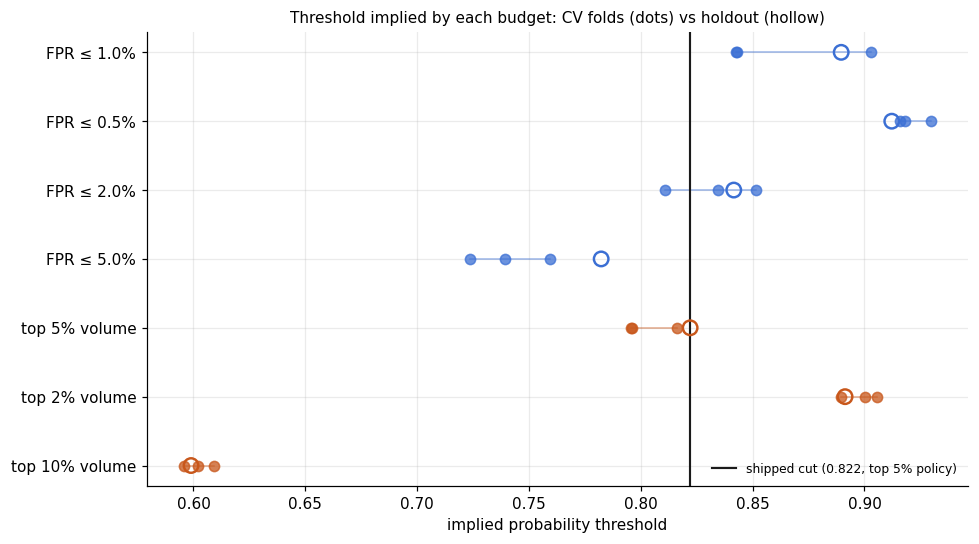

In [17]:
fig, ax = plt.subplots(figsize=(9, 0.55 * len(budgets) + 1.2))
for i, r in budgets.iterrows():
    b = r["budget"]
    fthr = (threshold_at_fpr(cell_cv, max_fpr=b, by=["fold"])["threshold"].astype(float)
            if r["family"] == "FPR budget" else cell_cv.groupby("fold")["y_score"].quantile(1 - b))
    col = fam_style[r["family"]][1]
    ax.scatter(fthr, np.full(len(fthr), i), s=45, color=col, alpha=0.75, zorder=3)
    ax.scatter([r["threshold"]], [i], s=90, facecolors="none", edgecolors=col, lw=1.6, zorder=4)
    ax.plot([r["fold_thr_min"], r["fold_thr_max"]], [i, i], color=col, lw=1, alpha=0.5)
ax.axvline(cut, color="#1a1a1a", lw=1.4, label=f"shipped cut ({cut:.3f}, top {PCT_BUDGETS[0]:.0%} policy)")
ax.set_yticks(range(len(budgets))); ax.set_yticklabels(budgets["label"]); ax.invert_yaxis()
ax.set_xlabel("implied probability threshold")
ax.set_title("Threshold implied by each budget: CV folds (dots) vs holdout (hollow)", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()

## Step 14 — from operating point to the production cut

Nothing above ever chose a probability threshold by hand. Training **fixes the operating
point** and the threshold *falls out* of the score distribution; `implied_thresholds`
derives both candidate cuts from the holdout scores — the `top_pct` (capacity) cut and the
`fpr` cut — and `metrics.decision_threshold_policy` decides which one ships. Both are
computed at the **first** entry of their budget list, which is why that ordering was a
decision, not an accident.

**How to read the chart:** the economics of every possible cut on the holdout — flag rate,
precision, recall as the threshold moves. The dotted lines are the FPR-budget cuts from
Step 13, the solid line is the shipped cut. Moving the cut left buys recall with analyst
hours; the curves price that trade explicitly, and the budget lines show where each
configured policy would land on it.

One caveat a report should state: on a model with few variables the score scale is
*discrete* (this one has under fifty distinct values), so many rows tie exactly at the cut
and the realised flag rate is sensitive to the last decimal of the stored threshold. That
is why `decision_flag_rate` in the bundle and the flag rate re-measured at the stored
value can differ by a few tenths of a percent — compare the two below.

{
 "implied_threshold_top_pct": 0.822057,
 "implied_threshold_at_fpr": 0.889591,
 "decision_threshold_policy": "top_pct",
 "decision_operating_point": 0.05,
 "decision_threshold": 0.822057,
 "decision_flag_rate": 0.052667,
 "decision_precision": 0.43038,
 "decision_recall": 0.21519
}

bundle threshold == implied[policy]: True

raw holdout quantile 0.8220566 -> stored in the bundle as 0.822057  | distinct holdout scores: 48
bundle says decision_flag_rate 5.27%; re-measured at the stored value: flag rate 4.80%, precision 44.4%, recall 20.3%, FPR 2.98%


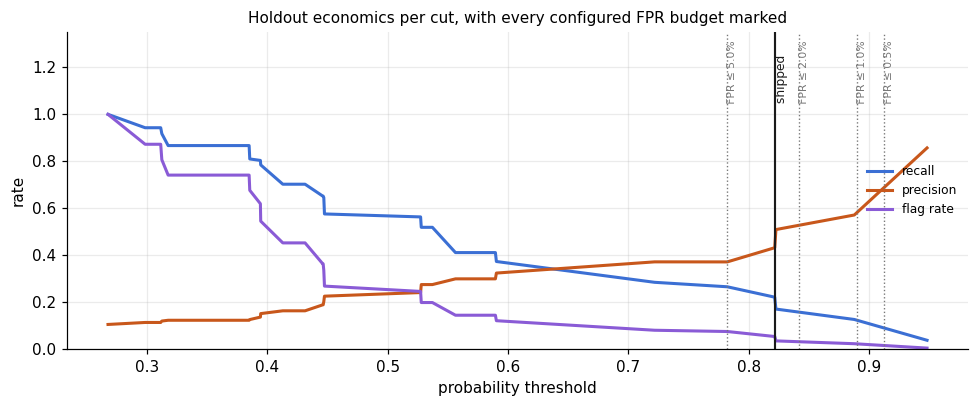

In [18]:
implied = implied_thresholds(y_ho, s_ho, meta)
print(json.dumps(implied, indent=1))
print("\nbundle threshold == implied[policy]:",
      np.isclose(meta["decision_threshold"], implied["decision_threshold"]))

grid = np.unique(np.round(np.quantile(s_ho, np.linspace(0.05, 0.995, 60)), 6))
opt = operating_point_table(ho, thresholds=grid, by=["model"])
fig, ax = plt.subplots(figsize=(9, 3.8))
for m, color in MEASURE.items():
    ax.plot(opt["threshold"], opt[m].astype(float), color=color, lw=2, label=m.replace("_", " "))
for _, r in budgets.query("family == 'FPR budget'").iterrows():
    ax.axvline(r["threshold"], color="#777", lw=0.9, ls=":")
    ax.text(r["threshold"], 1.03, f" {r['label']}", fontsize=7, color="#777", rotation=90, va="bottom")
ax.axvline(cut, color="#1a1a1a", lw=1.4)
ax.text(cut, 1.03, " shipped", fontsize=8, color="#1a1a1a", rotation=90, va="bottom")
ax.set_ylim(0, 1.35); ax.set_xlabel("probability threshold"); ax.set_ylabel("rate")
ax.set_title("Holdout economics per cut, with every configured FPR budget marked", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="center right")
plt.tight_layout()
raw_q = float(np.quantile(s_ho, 1 - PCT_BUDGETS[0]))
print(f"\nraw holdout quantile {raw_q:.7f} -> stored in the bundle as {cut}  "
      f"| distinct holdout scores: {len(np.unique(s_ho))}")
print(f"bundle says decision_flag_rate {implied['decision_flag_rate']:.2%}; re-measured at the stored value: "
      f"flag rate {at_cut['flag_rate']:.2%}, precision {at_cut['precision']:.1%}, "
      f"recall {at_cut['recall']:.1%}, FPR {at_cut['fpr']:.2%}")

## Step 15 — what leaves the harness

The harness's durable outputs are the winning **specification**, the **prediction store**,
and the fitted **bundle**. `model.joblib` was written with the derived
`decision_threshold` inside, and `ProductionScorer.from_joblib` picks it up — so
production applies the same stable absolute cut Step 14 justified, instead of an arbitrary
0.5 or a batch-relative quantile. (A later cost-based tuning pass overrides it:
`ProductionScorer(..., threshold=...)` wins over the bundle.)

Every scored row still carries a probability *and* a data-quality verdict: rows relying on
out-of-support input are routed to manual review, never auto-actioned.

In [19]:
scorer = ProductionScorer.from_joblib(f"{RUN_DIR}/model.joblib")
print(f"decision threshold from the bundle: {scorer.threshold:.4f} "
      f"(policy: {scorer.metadata['decision_threshold_policy']}, dmf {scorer.metadata['dmf_version']})")

fresh = generate_disputes(n=800, seed=99).drop(columns=[ID, TARGET])
scored, report = scorer.score(fresh)
print("batch verdict:", report["verdict"], "| flag rate:", f"{report['flag_rate']:.1%}",
      "| manual review:", report["n_manual_review"])
scored[["fraud_probability", "data_quality", "decision", "action"]].head(5)

decision threshold from the bundle: 0.8221 (policy: top_pct, dmf 0.2.0)


batch verdict: ok | flag rate: 4.1% | manual review: 33


,fraud_probability,data_quality,decision,action
0,0.381116,ok,pass,auto_action
1,0.515486,ok,pass,auto_action
2,0.545062,ok,pass,auto_action
3,0.287147,ok,pass,auto_action
4,0.326777,ok,pass,auto_action


## Step 16 — monitoring reference: is next month's score distribution the one we validated?

**What it is:** Population Stability Index (PSI) bins a new batch's scores by the quantiles
of a *reference* score distribution and measures how far the mass has moved; it is the
standard first drift check. **How to read it:** < 0.10 stable, 0.10–0.25 watch, > 0.25
investigate. PSI catches a shift *within* the training support; the inference guard
(`data_quality`) catches values *outside* it — a report should show both.

**Which reference?** The bundle carries `reference_score_quantiles`, taken from the
train-only fit's holdout scores. But `run.refit_on_full_data` (on by default) means the
pipeline that actually ships is a *different* fit, and on a model with a discrete score
scale the two can disagree badly — the first line below measures exactly that. So the
reference a monitoring report should use is **what the shipped model scores on the holdout
rows**, and that is what the batches are compared against here.

The second batch injects drift **into the model's own inputs** — an unseen category level
and a numeric value far outside the training range in ~12% of rows — because drift in a
column the model does not use is, correctly, invisible to both alarms. (The generator's
stock `drifted=True` batch perturbs columns this two-variable model never reads.)

Read `guarded_share` with the batch rule in mind: once the share of guarded *cells* in a
batch exceeds `inference_guard.max_guarded_rate` (5%), the guard marks the **whole batch**
unsafe and every row is routed to manual review — so a drifted batch shows 1.0 there and
`review_recommended`, not the 12% of rows that were actually touched.

bundle quantiles == quantiles of the stored (train-only) holdout scores: True
PSI(train-only reference vs shipped model, same rows) = 3.032 -> the stored reference is STALE after the refit; use the shipped model


,n,psi,band,flag_rate,guarded_share,verdict
batch,,,,,,
"next month, no drift",800,0.0265,stable,0.04125,0.0,ok
"next month, drift in model inputs",800,0.1636,watch,0.13250,1.0,review_recommended


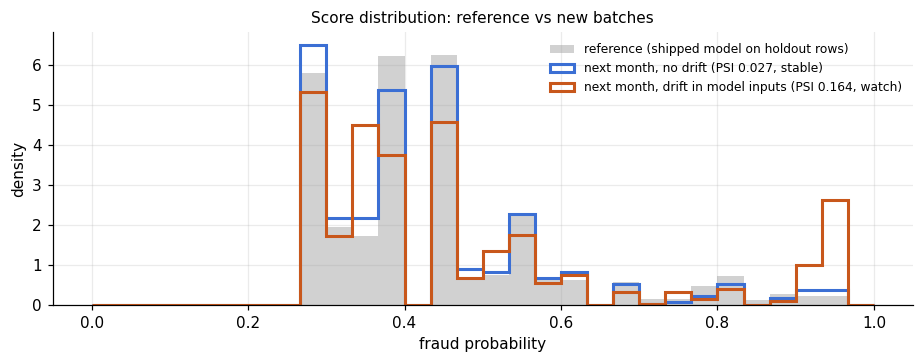

In [20]:
q_bundle = np.asarray(scorer.metadata["reference_score_quantiles"], float)
print("bundle quantiles == quantiles of the stored (train-only) holdout scores:",
      np.allclose(q_bundle, np.quantile(s_ho, np.linspace(0, 1, 21)), atol=1e-6))

# the reference that matters: the SHIPPED model, scored on the holdout rows
X_ho = df.set_index(ID).loc[ho["row_id"]].drop(columns=[TARGET])
ref = scorer.score(X_ho, return_report=False)["fraud_probability"].to_numpy()
stale_psi = population_stability_index(s_ho, ref)
print(f"PSI(train-only reference vs shipped model, same rows) = {stale_psi:.3f} -> "
      f"{'the stored reference is STALE after the refit; use the shipped model' if stale_psi > 0.25 else 'stored reference still valid'}")

fresh = generate_disputes(n=800, seed=99).drop(columns=[ID, TARGET])
drifted, rng = fresh.copy(), np.random.default_rng(0)
env = scorer.training_envelope().set_index("variable")
for f_ in scorer.features:                                   # drift the model's OWN inputs
    hit = rng.random(len(drifted)) < 0.12
    if env.loc[f_, "type"] == "numeric":
        drifted.loc[hit, f_] = float(env.loc[f_, "guard_max"]) * 4 + 1     # far outside the training range
    elif pd.api.types.is_numeric_dtype(drifted[f_]):
        drifted.loc[hit, f_] = int(drifted[f_].max()) * 4 + 1              # an integer level never seen
    else:
        drifted.loc[hit, f_] = "__NEW_LEVEL__"                             # a category never seen
batches = {"next month, no drift": fresh, "next month, drift in model inputs": drifted}
mon = []
fig, ax = plt.subplots(figsize=(8.5, 3.4))
bins = np.linspace(0, 1, 31)
ax.hist(ref, bins=bins, density=True, color="#999", alpha=0.45, label="reference (shipped model on holdout rows)")
for (name, X), col in zip(batches.items(), ["#3b6fd4", "#c8571b"]):
    sc, rp = scorer.score(X)
    psi = population_stability_index(ref, sc["fraud_probability"].to_numpy())
    mon.append({"batch": name, "n": len(X), "psi": round(psi, 4), "band": psi_band(psi),
                "flag_rate": rp["flag_rate"], "guarded_share": float((sc["data_quality"] == "guarded").mean()),
                "verdict": rp["verdict"]})
    ax.hist(sc["fraud_probability"], bins=bins, density=True, histtype="step", lw=2, color=col,
            label=f"{name} (PSI {psi:.3f}, {psi_band(psi)})")
ax.set_xlabel("fraud probability"); ax.set_ylabel("density")
ax.set_title("Score distribution: reference vs new batches", fontsize=10)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
mon = pd.DataFrame(mon).set_index("batch")
mon

## Step 17 — report manifest: what a model documentation report should contain

Everything above is written to the artifact folder. This cell maps each **report section**
to the **artifact files** that back it and the **headline numbers** a reader would expect
to see quoted — the contract between this run and whoever (or whatever) writes the
document. It is saved as `report_manifest.json` beside the other artifacts, so a report
can be generated from the folder alone, months later.

In [21]:
lineage = rep.get("lineage") or {}
sweep_records = budgets.round(4).to_dict(orient="records")
manifest = {
    "run": {"name": cfg.run.name, "artifact_dir": RUN_DIR,
            "config_sha256": lineage.get("config_sha256"), "data_sha256": lineage.get("data_sha256"),
            "dmf_version": scorer.metadata.get("dmf_version"),
            "selected": {"model": sel["model"], "k": k_sel, "features": sel["features"], "rule": sel["rule"]}},
    "sections": [
        {"section": "1. Population overview", "steps": [1, 4],
         "artifacts": ["run_report.json:data_load", "run_report.json:data_target",
                       "run_report.json:data_quality", "run_report.json:holdout_split"],
         "headline": {"n_rows": t["n_rows"], "prevalence": t["prevalence"], "n_train": s["n_train"],
                      "n_holdout": s["n_holdout"], "holdout_prevalence": s["holdout_prevalence"],
                      "expected_positives_per_fold": t["expected_positives_per_validation_fold"],
                      "thin_positive_folds": t["thin_positive_folds"]}},
        {"section": "2. Feature importance", "steps": [5, 6],
         "artifacts": ["orderings.json", "run_report.json:variable_ordering", "run_report.json:selection_stability"],
         "headline": {m: {"method": o["report"]["method"], "top5": o["ordering"][:5],
                          "cumulative_share_top5": o["report"]["cumulative_share_top5"]}
                      for m, o in result.orderings.items()} | {"always_selected": always}},
        {"section": "3. Training / CV stability", "steps": [6, 7, 12],
         "artifacts": ["leaderboard.csv", "predictions.parquet[stage=cv]", "predictions.parquet[stage=cv_train]",
                       "fold_assignments.parquet"],
         "headline": {"cv_scheme": rep.get("cv_grid")["cv_scheme"],
                      "selected_cv_ap": sel["cv_average_precision_mean"], "selected_cv_se": sel["cv_average_precision_se"],
                      "selected_overfit_gap": float(sel_row["overfit_gap"]),
                      "per_fold_ap_selected": per_fold.query("model == @best_model and k == @k_sel")["average_precision"].round(4).tolist()}},
        {"section": "4. Out-of-sample performance", "steps": [7, 8, 9, 10],
         "artifacts": ["leaderboard.csv", "marginal_gains.csv", "top_specs.json", "selected_spec.json", "holdout_metrics.json"],
         "headline": {"holdout_ap": hm["average_precision"], "holdout_roc_auc": hm["roc_auc"], "holdout_ks": hm["ks_statistic"],
                      "cv_minus_holdout_ap": round(sel["cv_average_precision_mean"] - hm["average_precision"], 4),
                      "cost_of_parsimony": sel["cost_of_parsimony"],
                      "first_non_improving_k": rep.get("marginal_gains")["first_non_improving_k"]}},
        {"section": "5. Holdout gains and segment parity", "steps": [10],
         "artifacts": ["holdout_deciles.csv", "holdout_slices.csv", "run_report.json:holdout_slices"],
         "headline": {"top_decile_lift": float(d.iloc[0]["lift"]), "top_decile_capture": float(d.iloc[0]["cumulative_capture"]),
                      "max_flag_rate_disparity": rep.get("holdout_slices")["max_flag_rate_disparity"],
                      "slice_columns": cfg.metrics.slice_columns}},
        {"section": "6. Metrics recomputed from stored predictions", "steps": [11, 12],
         "artifacts": ["predictions.parquet", "fold_assignments.parquet", "predictions_meta.json"],
         "headline": {"rows_per_stage": meta["rows_per_stage"], "leaderboard_reproduced_from_store": True,
                      "row_id_source": meta["row_id_source"]}},
        {"section": "7. Operating points and the production cut", "steps": [13, 14],
         "artifacts": ["holdout_metrics.json", "predictions_meta.json", "model.joblib:decision_threshold"],
         "headline": {"policy": meta["decision_threshold_policy"], "decision_operating_point": hm["decision_operating_point"],
                      "decision_threshold": meta["decision_threshold"],
                      "at_cut": {k_: float(at_cut[k_]) for k_ in ("flag_rate", "precision", "recall", "fpr")},
                      "fpr_budgets": FPR_BUDGETS, "review_budgets": PCT_BUDGETS,
                      "budget_sweep": sweep_records}},
        {"section": "8. Monitoring reference", "steps": [15, 16],
         "artifacts": ["model.joblib:reference_score_quantiles", "model.joblib:decision_threshold",
                       "predictions.parquet[stage=holdout]"],
         "headline": {"reference_used": "shipped model scored on the holdout rows",
                      "psi_stored_reference_vs_shipped_model": round(stale_psi, 4),
                      "batches": mon.round(4).to_dict(orient="index")}},
    ],
}
with open(f"{RUN_DIR}/report_manifest.json", "w") as fh:
    json.dump(json_safe(manifest), fh, indent=2)
print(f"wrote {RUN_DIR}/report_manifest.json")
pd.DataFrame([{"section": x["section"], "steps": x["steps"], "artifacts": ", ".join(x["artifacts"]),
               "headline keys": ", ".join(x["headline"])} for x in manifest["sections"]]).set_index("section")

wrote ./artifacts_demo/walkthrough/report_manifest.json


,steps,artifacts,headline keys
section,,,
1. Population overview,"[1, 4]","run_report.json:data_load, run_report.json:dat...","n_rows, prevalence, n_train, n_holdout, holdou..."
2. Feature importance,"[5, 6]","orderings.json, run_report.json:variable_order...","logistic, gbm, always_selected"
3. Training / CV stability,"[6, 7, 12]","leaderboard.csv, predictions.parquet[stage=cv]...","cv_scheme, selected_cv_ap, selected_cv_se, sel..."
4. Out-of-sample performance,"[7, 8, 9, 10]","leaderboard.csv, marginal_gains.csv, top_specs...","holdout_ap, holdout_roc_auc, holdout_ks, cv_mi..."
5. Holdout gains and segment parity,[10],"holdout_deciles.csv, holdout_slices.csv, run_r...","top_decile_lift, top_decile_capture, max_flag_..."
6. Metrics recomputed from stored predictions,"[11, 12]","predictions.parquet, fold_assignments.parquet,...","rows_per_stage, leaderboard_reproduced_from_st..."
7. Operating points and the production cut,"[13, 14]","holdout_metrics.json, predictions_meta.json, m...","policy, decision_operating_point, decision_thr..."
8. Monitoring reference,"[15, 16]","model.joblib:reference_score_quantiles, model....","reference_used, psi_stored_reference_vs_shippe..."


## Recap — how each step constrains the next

1. **Population** is the denominator of every claim that follows.
2. **Config** defines the search space; nothing downstream adds to it — including the
   budget lists, which fix which operating points exist to be reported.
3. **Importance and ordering (per fold)** decide *which* variable subsets exist — the grid
   can't score a subset the ranking never proposed; stability tells you how trustworthy
   those subsets are.
4. **Leaderboard** measures every (model, k) honestly, at every budget; its plateau
   *suggests* where to stop.
5. **Marginal gains** turn the plateau into per-variable evidence.
6. **1-SE selection** converts that evidence into a single parsimonious spec.
7. **Holdout** is the only number untouched by the search — quote it, and check its slices.
8. **Prediction store** keeps the row-level evidence behind every number above, so any
   metric — configured or not, at any budget — is recomputable post-run, no refit.
9. **Budgets** are points on one curve: AP does not move, the threshold and everything
   downstream of it does. The first entry of each list is the one that ships.
10. **Monitoring** compares tomorrow's scores against the reference the bundle carries.
11. **The manifest** ties every report section to the artifact and the number that backs it.

Full-scale run: `python -m dmf.research.cli train --config ../configs/dispute_fraud_v2.yaml`.
Compare alternative configs honestly: `python -m dmf.research.cli sweep --configs a.yaml b.yaml`.
All tables shown here are written as CSVs under `artifacts_demo/walkthrough/`, alongside
`predictions.parquet`, `fold_assignments.parquet`, `predictions_meta.json` and
`report_manifest.json` — the store travels with the run, so every chart in Steps 11–17 can
be rebuilt months later from the artifact folder alone.